In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [2]:
# Random distribution
np.random.seed(0)

In [3]:
# Set default properties
default_props = dict(
  t_b = 1e14,
  t_d = 5e10,
  K_crust = 10e9,
  G_crust = 10e9,
  K_f = 10e9,
  rho0 = 2500,
  r_hydr = 5,
  mu0 = 1e6,
  R_min = 500,
  R_max = 500,
  N_chamber = 25,
  x_scale = 40e3,
  z_scale = 40e3,
  mass_in_rate = 3.0,
  p_erupt = 5e6,
  dpdx_crit = 1e3,
  dpdx_threshold_scale = 0.0,
  mu_erupt = 1e5,
  r_conduit_erupt = 25,
)

In [5]:
def generate_and_save_run(id:str, props, seed=None):

  if seed is not None:
    np.random.seed(seed)

  t_b = props["t_b"]
  t_d = props["t_d"]
  K_crust = props["K_crust"]
  G_crust = props["G_crust"]
  K_f = props["K_f"]
  r_hydr = props["r_hydr"]
  mu0 = props["mu0"]
  R_min = props["R_min"]
  R_max = props["R_max"]
  N_chamber = props["N_chamber"]
  x_scale = props["x_scale"]
  z_scale = props["z_scale"]

  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3
  # List generation of chamber characteristics
  x_nodes = x_scale * np.random.rand(N_chamber)
  y_nodes = 0.0 * np.random.rand(N_chamber)
  z_nodes = np.linspace(0.0, z_scale, N_chamber)
  # Fix bottom and top nodes
  z_nodes[0] = 0.0
  z_nodes[-1] = z_scale
  x_nodes[0] = 0.5 * x_scale
  x_nodes[-1] = 0.5 * x_scale

  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=props["dpdx_crit"],
                                    dpdx_threshold_scale=props["dpdx_threshold_scale"],#1e2,
                                    R_outer_ratio=20, # numerical R(infty) / R0
                                    max_edge_dist=np.inf)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(props["mass_in_rate"])
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=props["p_erupt"],
                                              mu_erupt=props["mu_erupt"],
                                              r_conduit=props["r_conduit_erupt"])

  # Primary simulation
  t_vec = np.linspace(0, 1e11, 1600)
  print(f"Starting simulation with id {id}.")
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

  # Save output
  print(f"Saving simulation to npz file ``output_{id}''.")

  np.savez_compressed(f"output_{id}", q_out=q_out, m_erupted_out=m_erupted_out, props=props)


In [4]:
def generate_system(props, seed=None):

  if seed is not None:
    np.random.seed(seed)

  t_b = props["t_b"]
  t_d = props["t_d"]
  K_crust = props["K_crust"]
  G_crust = props["G_crust"]
  K_f = props["K_f"]
  r_hydr = props["r_hydr"]
  mu0 = props["mu0"]
  R_min = props["R_min"]
  R_max = props["R_max"]
  N_chamber = props["N_chamber"]
  x_scale = props["x_scale"]
  z_scale = props["z_scale"]

  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3
  # List generation of chamber characteristics
  x_nodes = x_scale * np.random.rand(N_chamber)
  y_nodes = 0.0 * np.random.rand(N_chamber)
  z_nodes = np.linspace(0.0, z_scale, N_chamber)
  # Fix bottom and top nodes
  z_nodes[0] = 0.0
  z_nodes[-1] = z_scale
  x_nodes[0] = 0.5 * x_scale
  x_nodes[-1] = 0.5 * x_scale

  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=props["dpdx_crit"],
                                    dpdx_threshold_scale=props["dpdx_threshold_scale"],#1e2,
                                    R_outer_ratio=20, # numerical R(infty) / R0
                                    max_edge_dist=np.inf)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(props["mass_in_rate"])
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=props["p_erupt"],
                                              mu_erupt=props["mu_erupt"],
                                              r_conduit=props["r_conduit_erupt"])

  # Primary simulation
  t_vec = np.linspace(0, 1e11, 16000)
  return global_sys, t_vec, f_inj, f_erupt

In [5]:
global_sys, t_vec, f_inj, f_erupt = generate_system(default_props, seed=0)

In [6]:
# generate_and_save_run("b0", default_props, seed=0)

Starting simulation with id b0.
Saving simulation to npz file ``output_b0''.


In [7]:
for i in range(25):
  np.load(f"output_A{i:04d}.npz")

In [135]:
i = 24
dat = np.load(f"output_A{i:04d}.npz", allow_pickle=True)
# list(dat.keys())
# ['q_out', 'm_erupted_out', 'props']

In [6]:
def post(dat):
  q_out = dat["q_out"]

  m_hist = q_out[:,global_sys.mass_indices]
  gamma_drr = q_out[global_sys.data_slice_global(0, "gamma_drr")]
  gamma_kk = q_out[global_sys.data_slice_global(0, "gamma_kk")]
  gamma_rr = gamma_drr + gamma_kk/3.0

  p = np.array([global_sys.pressure(q_out[i_t,:]) for i_t in range(q_out.shape[0])])
  props:dict = np.array(dat["props"], ndmin=1)[0]
  stored_mass = m_hist.sum(axis=1) - m_hist.sum(axis=1)[0]
  added_mass  = t_vec.copy() * props["mass_in_rate"]
  erupted_mass = added_mass - stored_mass

  return m_hist, gamma_rr, p, erupted_mass, props

In [7]:
tups = []
for i in range(96):
  # m_hist, gamma_rr, p, erupted_mass = post(np.load(f"output_A2{i:04d}.npz", allow_pickle=True))
  # tups
  tups.append(post(np.load(f"output_A2{i:04d}.npz", allow_pickle=True)))
  # print(i)



In [8]:
def window_avg(p, N=100):
  return np.convolve(p, np.ones(N)/N, mode='valid')

# plt.plot(p[:,0,:].squeeze())



In [10]:
''' Regression-based steady-state evaluation '''

import scipy.optimize
# fit_params, fit_cov = scipy.optimize.curve_fit(lambda x, scale, rate: scale * (1 - np.exp(rate*x)),
#                                                t_vec[:-1:5]/t_vec[-1], p[:-1:5,0,:].squeeze() / float(p[-2,0,:]),
#                                                p0 = (1, -1,))
# plt.plot(t_vec[:-1:50]/t_vec[-1], p[:-1:50,0,:].squeeze() / float(p[-2,0,:]))
# fit_params
# plt.plot(t_vec/t_vec[-1], 1.00166329 * (1 - np.exp(t_vec/t_vec[-1] * -2.72376311)))

(0.0, 62155580.986338384)

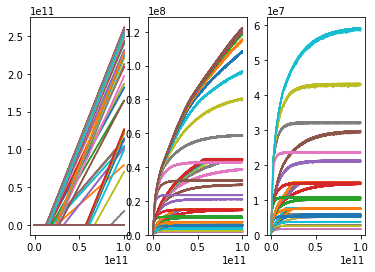

In [11]:
equilibration_scores = np.zeros(len(tups))
steady_state_inlet_pressure = np.full((len(tups),), np.nan)
effective_conductivity = (np.zeros((len(tups),)))
is_steady_state_reached = np.full((len(tups),), False)
for i in range(96):
  m_hist, gamma_rr, p, erupted_mass, props = tups[i]
  plt.subplot(1,3,1)
  plt.plot(t_vec, erupted_mass)
  plt.subplot(1,3,2)
  plt.plot(t_vec, p[:,0,:])
  # plt.ylim(bottom=0)
  plt.subplot(1,3,3)
  p_filtered = window_avg(p[:,0,:].squeeze(), N=10)
  dpdt = np.diff(p_filtered, axis=0) / (t_vec[1] - t_vec[0])
  terminal_rate = (dpdt[:-1] / float(p[-1,0,:]) * t_vec[-1])[-1]
  # Exp. decay fit to pressure
  fit_params, fit_cov = scipy.optimize.curve_fit(lambda x, scale, rate: scale * (1 - np.exp(-rate*x)),
    t_vec[:-1]/t_vec[-1], p[:-1,0,:].squeeze() / p_filtered[-1],
    p0 = (1, 1,))
  # Extract pressure equilibration scale, equilibration relative timescale
  fit_scale, fit_rate = fit_params
  equilibration_scores[i] = 1 - np.exp(-fit_rate)
  steady_state_inlet_pressure[i] = p[-1,0,:]
  effective_conductivity[i] = props["mass_in_rate"] / p[-1,0,:]
  if equilibration_scores[i] > 0.999:
    plt.plot(t_vec, p[:,0,:])
    # plt.plot(t_vec, p_filtered[-1] * fit_scale * (1 - np.exp(-fit_rate * t_vec / t_vec[-1])))
    is_steady_state_reached[i] = True
  else:
    is_steady_state_reached[i] = False

plt.subplot(1,3,2)
plt.ylim((0, plt.ylim()[1]))
plt.subplot(1,3,3)
plt.ylim((0, plt.ylim()[1]))


In [12]:
# Set A2 params
t_d_range = 5e10 * 2.0**np.arange(-6,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-6,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)
mg_t_d.shape
t_d_range = 5e10 * 2.0**np.arange(-5,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-7,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)

In [13]:
import scipy.spatial.distance
node_pos = [[node.x, node.z] for node in global_sys.nodes]
# _dists = scipy.spatial.distance.cdist(node_pos, node_pos)
# Compute 2D characteristic spacing
char_area = np.prod(np.max(node_pos, axis=0) - np.min(node_pos, axis=0))
char_spacing = np.sqrt(char_area / len(global_sys.nodes))
char_dpdx = props["p_erupt"] / char_spacing

# 1 / timescale for mass injection
input_rate = props["mass_in_rate"] / global_sys.nodes[0].m0


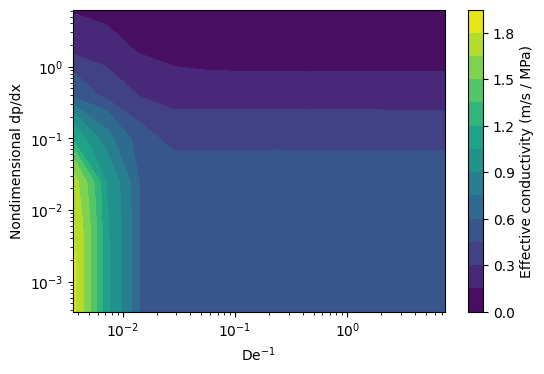

In [ ]:
plt.figure(dpi=100)
plt.contourf((mg_t_d) * input_rate, (mg_dpdx_crit) / char_dpdx, 1e6 * np.reshape(effective_conductivity, mg_t_d.shape), levels=15)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("De${}^{-1}$")
plt.ylabel("Minimum pressure gradient, nondimensionalized")

plt.colorbar(label="Effective conductivity (m/s / MPa)")

$$
u \sim \frac{k}{\eta} \frac{dp}{dz} \sim \frac{K_\mathrm{D}}{\phi} \frac{\Delta p}{\Delta z}
$$
where $u$ is liquid velocity relative to solid matrix, and $p$ is pressure in excess of hydrostatic. For a single hydraulic connection from bottom of the crust to the surface, we modeled as a single pipe flow
$$
u \sim \frac{R^2}{16 \mu_0} \frac{\Delta p}{\Delta z}
$$

In [354]:
dz = np.max(node_pos, axis=0)[1] - np.min(node_pos, axis=0)[1]
cond_single_pipe = props["r_hydr"]**2 / 16.0 / props["mu0"]

Compare to equivalent k / eta: 


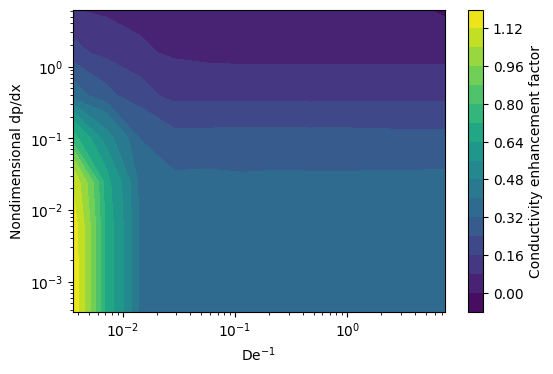

In [355]:
print("Compare to equivalent k / eta: ")
plt.figure(dpi=100)
plt.contourf((mg_t_d) * input_rate, (mg_dpdx_crit) / char_dpdx, 1/cond_single_pipe * np.reshape(effective_conductivity, mg_t_d.shape), levels=15)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("De${}^{-1}$")
plt.ylabel("Nondimensional dp/dx")

plt.colorbar(label="Conductivity enhancement factor")

In [241]:
equilibration_scores

array([51.07938202, 21.28427632,  9.68123299, 12.45641887, 14.01902729,
       14.71576328, 15.0444545 , 15.2048217 , 15.28470432, 15.32365097,
       15.3439624 , 15.34585541, 51.1060901 , 21.28983861,  9.68259476,
       12.43532842, 13.9985744 , 14.69265412, 15.02397942, 15.18400654,
       15.26570266, 15.3054036 , 15.32344261, 15.3295498 , 51.71407358,
       21.42914514,  9.71824392, 12.34252454, 13.9150266 , 14.61645703,
       14.94788958, 15.11111665, 15.19293976, 15.23125459, 15.2525539 ,
       15.25771318, 54.27166989, 22.18138312,  9.91682998, 11.8511916 ,
       13.44991437, 14.15802861, 14.49549597, 14.65878347, 14.7398035 ,
       14.77947794, 14.79909536, 14.80985186, 69.27984996, 29.64957052,
       11.92122852, 10.94169044, 12.64828664, 13.4054068 , 13.7688334 ,
       13.94788162, 14.04112675, 14.08808719, 14.11033945, 14.12305838,
       62.43264843, 31.29101921, 17.11752047,  8.34352087,  9.58585021,
       10.45049268, 10.85061469, 11.03470075, 11.12808397, 11.17

In [ ]:
tups = []
for i in range(96):
  m_hist, gamma_rr, p, erupted_mass = tups[i]
  plt.plot(t_vec, p)

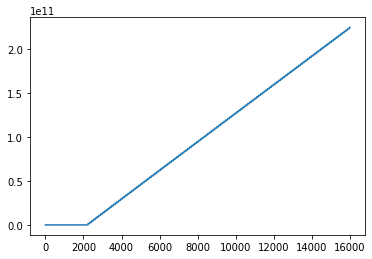

In [147]:

plt.plot(erupted_mass)

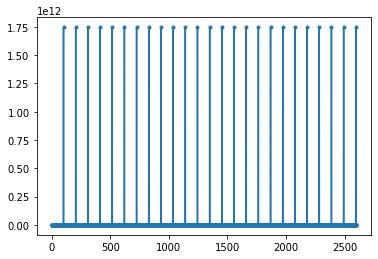

In [146]:
plt.plot(gamma_rr[-1,:], '.-')

In [109]:
t_vec

array([0.00000000e+00, 6.25039065e+06, 1.25007813e+07, ...,
       9.99874992e+10, 9.99937496e+10, 1.00000000e+11])

Text(0, 0.5, 'Erupted mass ($10^9$ kg)')

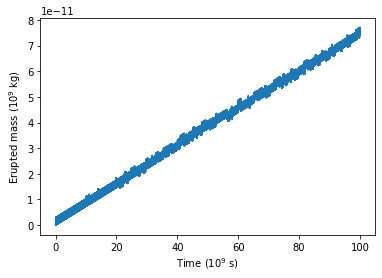

In [130]:
stored_mass = m_hist.sum(axis=1) - m_hist.sum(axis=1)[0]
added_mass  = t_vec.copy() * props["mass_in_rate"]
erupted_mass = added_mass - stored_mass
plt.plot(t_vec/1e9, erupted_mass / 1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Erupted mass ($10^9$ kg)")

# plt.plot(t_vec[1:], erupted_mass)
# plt.plot(t_vec, added_mass)

In [55]:
m_hist.shape

(16000, 25)

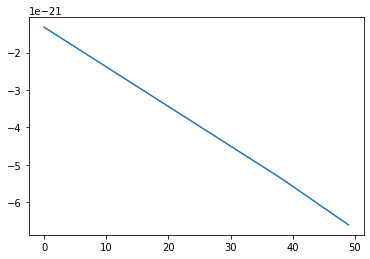

In [40]:
plt.plot(gamma_rr[:,-10])

In [28]:
global_sys.data_slice_global(0, "gamma_drr")
global_sys.data_slice_global(0, "gamma_kk")


slice(50, 100, None)

In [ ]:
4.0**np.arange(-2,3)

array([ 0.0625,  0.25  ,  1.    ,  4.    , 16.    ])

In [ ]:
_X = 9
f"{_X:03d}"

'009'

In [ ]:
# Series A: t_d and dpdx_crit
t_d_range = 5e10 * 4.0**np.arange(-2,3)
dpdx_crit_range = 1e3 * 4.0**np.arange(-2,3)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)

for i, (t_d, dpdx_crit) in enumerate(zip(mg_t_d.ravel(), mg_dpdx_crit.ravel())):
  props = default_props.copy()
  props["t_d"] = t_d
  props["t_b"] = t_d
  props["dpdx_crit"] = dpdx_crit
  # print(f"A{i:04d}")
  generate_and_save_run(f"A{i:04d}", props, seed=0)

Starting simulation with id A0000.
Saving simulation to npz file ``output_A0000''.
Starting simulation with id A0001.
Saving simulation to npz file ``output_A0001''.
Starting simulation with id A0002.
Saving simulation to npz file ``output_A0002''.
Starting simulation with id A0003.
Saving simulation to npz file ``output_A0003''.
Starting simulation with id A0004.
Saving simulation to npz file ``output_A0004''.
Starting simulation with id A0005.
Saving simulation to npz file ``output_A0005''.
Starting simulation with id A0006.
Saving simulation to npz file ``output_A0006''.
Starting simulation with id A0007.
Saving simulation to npz file ``output_A0007''.
Starting simulation with id A0008.
Saving simulation to npz file ``output_A0008''.
Starting simulation with id A0009.
Saving simulation to npz file ``output_A0009''.
Starting simulation with id A0010.
Saving simulation to npz file ``output_A0010''.
Starting simulation with id A0011.
Saving simulation to npz file ``output_A0011''.
Star

In [ ]:
t_d_range = 5e10 * 2.0**np.arange(-6,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-6,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)
mg_t_d.shape

(7, 13)

In [ ]:
# Series A2: t_d and dpdx_crit redone
t_d_range = 5e10 * 2.0**np.arange(-5,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-7,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)

for i, (t_d, dpdx_crit) in enumerate(zip(mg_t_d.ravel(), mg_dpdx_crit.ravel())):
  props = default_props.copy()
  props["t_d"] = t_d
  props["t_b"] = t_d
  props["dpdx_crit"] = dpdx_crit
  generate_and_save_run(f"A2{i:04d}", props, seed=0)

Starting simulation with id A20000.
Saving simulation to npz file ``output_A20000''.
Starting simulation with id A20001.
Saving simulation to npz file ``output_A20001''.
Starting simulation with id A20002.
Saving simulation to npz file ``output_A20002''.
Starting simulation with id A20003.
Saving simulation to npz file ``output_A20003''.
Starting simulation with id A20004.
Saving simulation to npz file ``output_A20004''.
Starting simulation with id A20005.
Saving simulation to npz file ``output_A20005''.
Starting simulation with id A20006.
Saving simulation to npz file ``output_A20006''.
Starting simulation with id A20007.
Saving simulation to npz file ``output_A20007''.
Starting simulation with id A20008.
Saving simulation to npz file ``output_A20008''.
Starting simulation with id A20009.
Saving simulation to npz file ``output_A20009''.
Starting simulation with id A20010.
Saving simulation to npz file ``output_A20010''.
Starting simulation with id A20011.
Saving simulation to npz file

In [ ]:
# Series B: K_f as an exsolved-volatile proxy
K_f_range = 10e9 * 4.0**np.arange(-4,1)

for i, K_f in enumerate(K_f_range):
  props = default_props.copy()
  props["K_f"] = K_f
  generate_and_save_run(f"B{i:04d}", props, seed=0)

Starting simulation with id B0000.
Saving simulation to npz file ``output_B0000''.
Starting simulation with id B0001.
Saving simulation to npz file ``output_B0001''.
Starting simulation with id B0002.
Saving simulation to npz file ``output_B0002''.
Starting simulation with id B0003.
Saving simulation to npz file ``output_B0003''.
Starting simulation with id B0004.
Saving simulation to npz file ``output_B0004''.


#### Read and reduce: Series A

In [ ]:
out = np.load("output_A0000.npz")
list(out.keys())

['q_out', 'm_erupted_out', 'props']

In [ ]:
out["m_erupted_out"]

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
tracks = [None for i in range(25)]
for i in range(25):
  out = np.load(f"output_A{i:04d}.npz")
  tracks[i] = out["m_erupted_out"]


In [ ]:
np.array(tracks).shape

(25, 16000)

$$
De = \frac{t_\mathrm{inj}}{t_\mathrm{d}}
= \frac{1}{t_\mathrm{d}} \frac{m_\mathrm{chamber}}{\dot{m}_\mathrm{inj}}
$$

In [ ]:
# Compute initial mass of a chamber
m0 = (4*np.pi/3) * default_props["R_max"] ** 3 * default_props["rho0"]
mdot_inj = default_props["mass_in_rate"]

De = m0 / mdot_inj / mg_t_d

m_tot = default_props["mass_in_rate"] * t_vec[-1]

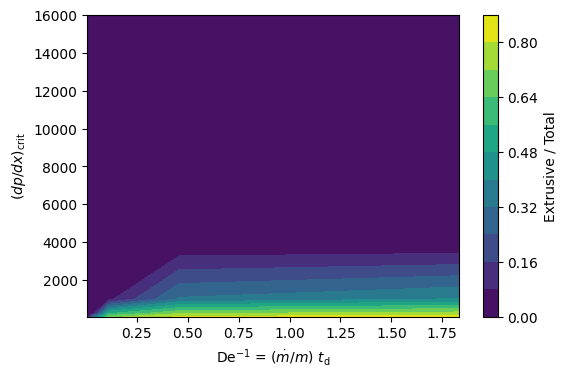

In [ ]:
plt.figure(dpi=100)
m_final = np.reshape(np.array(tracks)[:,-1], mg_t_d.shape)
plt.contourf(1/De, mg_dpdx_crit, m_final / m_tot,
             levels=10)
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("$(dp/dx)_\mathrm{crit}$")
plt.colorbar(label="Extrusive / Total")

Text(0, 0.5, 'Extrusive / Total at final time')

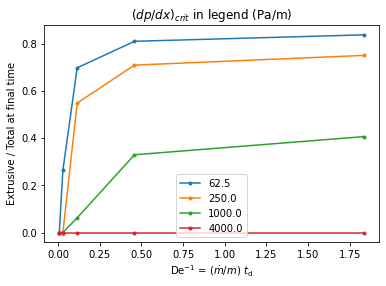

In [ ]:
for i in range(4):
  plt.plot(1/De[i,:], m_final[i,:] / m_tot, '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Extrusive / Total at final time")

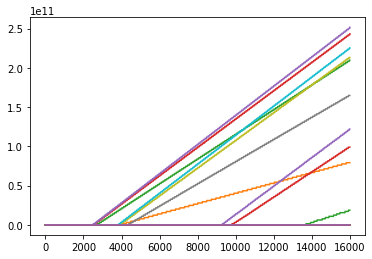

In [ ]:
plt.plot(np.array(tracks).T);

Text(0, 0.5, 'Inter-eruption period ($10^9$ s)')

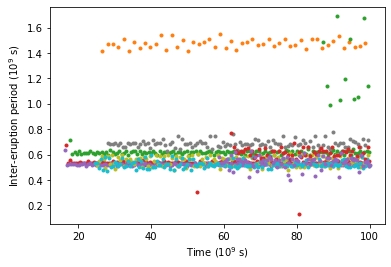

In [ ]:
# Edge detection

t_cell = 0.5 * (t_vec[:-1] + t_vec[1:])
dt_vec = t_vec[1:] - t_vec[:-1]

grads = np.diff(np.array(tracks), axis=1)

avg_period = [np.inf for i in range(grads.shape[0])]
onset_times = [np.inf for i in range(grads.shape[0])]

for i in range(grads.shape[0]):

  t_idx_eruption = np.where(np.abs(grads[i,:]) > 0.001)

  intereruptions = np.diff(t_cell[t_idx_eruption])

  plt.plot(t_cell[t_idx_eruption][1:] / 1e9, intereruptions / 1e9, '.')
# plt.xlabel("Eruption count")
# plt.ylabel("Time $\Delta t$ since last eruption ($10^9$ s)")
# ax2y = plt.gca().secondary_yaxis('right', functions=(
#   lambda t: t * 1e9 / (dt_vec[0]),
#   lambda tau: tau * dt_vec[0] / 1e9))
# ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

  if intereruptions.size > 0:
    avg_period[i] = np.mean(intereruptions)
  if t_idx_eruption[0].size > 0:
    onset_times[i] = t_cell[t_idx_eruption[0][0]]

plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Inter-eruption period ($10^9$ s)")

Text(0, 0.5, 'Inter-eruption interval ($10^9$ s)')

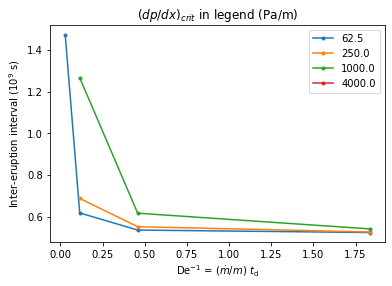

In [ ]:
for i in range(4):
  plt.plot(1/De[i,:], np.reshape(avg_period, De.shape)[i,:] / 1e9,
  '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Inter-eruption interval ($10^9$ s)")

Text(0, 0.5, 'Time to first eruption ($10^9$ s)')

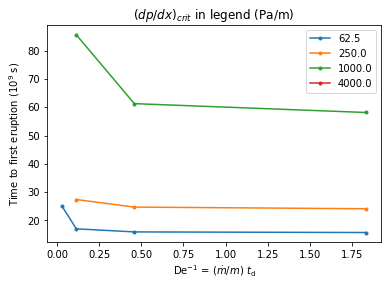

In [ ]:
for i in range(4):
  plt.plot(1/De[i,:], np.reshape(onset_times, De.shape)[i,:] / 1e9,
  '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Time to first eruption ($10^9$ s)")

#### Read and reduce: Series B

In [ ]:
tracksB = [None for i in range(5)]
for i in range(5):
  out = np.load(f"output_B{i:04d}.npz")
  tracksB[i] = out["m_erupted_out"]


In [ ]:
np.array(tracksB).max()

0.0

In [ ]:
out["props"]

ValueError: Object arrays cannot be loaded when allow_pickle=False